# Lib

In [1]:
# !pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import os
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [3]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.10.0+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4
capability: (7, 5)


# Data

In [4]:
dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")
image_dir = dataset_dir / "images" / "images"
annotation_path = dataset_dir / "labels" / "annotations.csv"

annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
0,train_00000.jpeg,2448,3264,1301,1546,1641,2096,albopictus
1,train_00001.jpeg,3024,4032,900,1897,1950,2990,albopictus
2,train_00002.jpeg,768,1024,220,58,659,808,albopictus
3,train_00003.jpeg,3456,4608,1169,2364,1586,2826,albopictus
4,train_00004.jpeg,1024,1365,129,231,697,1007,culex


In [5]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10357
class_label
albopictus            4612
culex                 4563
culiseta               622
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000.jpeg,albopictus
1,train_00001.jpeg,albopictus
2,train_00002.jpeg,albopictus
3,train_00003.jpeg,albopictus
4,train_00004.jpeg,culex


# Preprocessing

In [6]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

In [7]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7249
Val: 1554
Test: 1554


In [8]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Full Train:", len(train_df))
print("Full Val:", len(val_df))
print("Full Test:", len(test_df))


Full Train: 7249
Full Val: 1554
Full Test: 1554


In [9]:
train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)

val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

print("Subset Train:", len(train_subset_df))
print("Subset Val:", len(val_subset_df))
print("Subset Test:", len(test_subset_df))

Subset Train: 283
Subset Val: 99
Subset Test: 100


/tmp/ipykernel_24/1350935851.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_24/1350935851.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_24/1350935851.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

# Modeling

## ENV

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Using: cuda
GPU: Tesla T4
Capability: (7, 5)


## Transform

In [11]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Dataset

In [12]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.image_dir / row["img_fName"]
        image = Image.open(image_path).convert("RGB")
        label = int(row["label_id"])

        if self.transform:
            image = self.transform(image)

        return image, label


In [13]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [14]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 196MB/s]


In [15]:
for param in model.features.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [16]:
output_dir = Path("/kaggle/working/")
output_dir.mkdir(parents=True, exist_ok=True)

num_epochs = 25
patience = 3
best_val_loss = float("inf")
early_stop_counter = 0

print("Start training...")
print("Selected device:", device)
print("Model device:", next(model.parameters()).device)

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch + 1}/{num_epochs} =====")
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        if batch_idx == 0:
            print("Before move:")
            print("  images device:", images.device)
            print("  labels device:", labels.device)

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if batch_idx == 0:
            print("After move:")
            print("  images device:", images.device)
            print("  labels device:", labels.device)
            print("  model device:", next(model.parameters()).device)

            if torch.cuda.is_available():
                print("  GPU memory allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
                print("  GPU memory reserved:", torch.cuda.memory_reserved() / 1024**2, "MB")

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % 10 == 0:
            print(f"[Train] Epoch {epoch + 1} Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            if batch_idx % 10 == 0:
                print(f"[Val] Epoch {epoch + 1} Batch {batch_idx}/{len(val_loader)} | Loss: {loss.item():.4f}")

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    checkpoint_path = output_dir / f"checkpoint_epoch_{epoch + 1}.pth"
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "class_names": class_names
    }, checkpoint_path)

    print(f"Saved checkpoint to: {checkpoint_path}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0

        best_model_path = output_dir / "best_model.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "class_names": class_names
        }, best_model_path)

        print(f"Best model updated and saved to: {best_model_path}")
    else:
        early_stop_counter += 1
        print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Early stopping triggered.")
        break

print("Training completed.")

Start training...
Selected device: cuda
Model device: cuda:0

===== Epoch 1/25 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 33.92919921875 MB
  GPU memory reserved: 54.0 MB
[Train] Epoch 1 Batch 0/227 | Loss: 1.7323
[Train] Epoch 1 Batch 10/227 | Loss: 1.6877
[Train] Epoch 1 Batch 20/227 | Loss: 1.6114
[Train] Epoch 1 Batch 30/227 | Loss: 1.6365
[Train] Epoch 1 Batch 40/227 | Loss: 1.6453
[Train] Epoch 1 Batch 50/227 | Loss: 1.6547
[Train] Epoch 1 Batch 60/227 | Loss: 1.6030
[Train] Epoch 1 Batch 70/227 | Loss: 1.5262
[Train] Epoch 1 Batch 80/227 | Loss: 1.5695
[Train] Epoch 1 Batch 90/227 | Loss: 1.6756
[Train] Epoch 1 Batch 100/227 | Loss: 1.5257
[Train] Epoch 1 Batch 110/227 | Loss: 1.5919
[Train] Epoch 1 Batch 120/227 | Loss: 1.6414
[Train] Epoch 1 Batch 130/227 | Loss: 1.5322
[Train] Epoch 1 Batch 140/227 | Loss: 1.5706
[Train] Epoch 1 Batch 150/227 | Loss: 1.

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 1 Batch 0/49 | Loss: 1.4940
[Val] Epoch 1 Batch 10/49 | Loss: 1.4327
[Val] Epoch 1 Batch 20/49 | Loss: 1.5389
[Val] Epoch 1 Batch 30/49 | Loss: 1.4996
[Val] Epoch 1 Batch 40/49 | Loss: 1.4589
Epoch 1/25 | Train Loss: 1.5473 | Train Acc: 0.4287 | Val Loss: 1.4874 | Val Acc: 0.4781
Saved checkpoint to: /kaggle/working/checkpoint_epoch_1.pth
Best model updated and saved to: /kaggle/working/best_model.pth

===== Epoch 2/25 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 52.05126953125 MB
  GPU memory reserved: 502.0 MB
[Train] Epoch 2 Batch 0/227 | Loss: 1.4918
[Train] Epoch 2 Batch 10/227 | Loss: 1.5103
[Train] Epoch 2 Batch 20/227 | Loss: 1.4668
[Train] Epoch 2 Batch 30/227 | Loss: 1.3943
[Train] Epoch 2 Batch 40/227 | Loss: 1.4136
[Train] Epoch 2 Batch 50/227 | Loss: 1.5140
[Train] Epoch 2 Batch 60/227 | Loss: 1.3832
[Train] Epoch 2 Batch 70/227 | Loss: 1.3

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 2 Batch 0/49 | Loss: 1.3976
[Val] Epoch 2 Batch 10/49 | Loss: 1.3025
[Val] Epoch 2 Batch 20/49 | Loss: 1.4585
[Val] Epoch 2 Batch 30/49 | Loss: 1.4174
[Val] Epoch 2 Batch 40/49 | Loss: 1.3474
Epoch 2/25 | Train Loss: 1.3833 | Train Acc: 0.4947 | Val Loss: 1.3801 | Val Acc: 0.5251
Saved checkpoint to: /kaggle/working/checkpoint_epoch_2.pth
Best model updated and saved to: /kaggle/working/best_model.pth

===== Epoch 3/25 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 52.05126953125 MB
  GPU memory reserved: 502.0 MB
[Train] Epoch 3 Batch 0/227 | Loss: 1.3010
[Train] Epoch 3 Batch 10/227 | Loss: 1.3645
[Train] Epoch 3 Batch 20/227 | Loss: 1.1513
[Train] Epoch 3 Batch 30/227 | Loss: 1.2811
[Train] Epoch 3 Batch 40/227 | Loss: 1.1855
[Train] Epoch 3 Batch 50/227 | Loss: 1.2194
[Train] Epoch 3 Batch 60/227 | Loss: 1.2456
[Train] Epoch 3 Batch 70/227 | Loss: 1.4

...

[Val] Epoch 16 Batch 0/49 | Loss: 1.0905
[Val] Epoch 16 Batch 10/49 | Loss: 0.9164
[Val] Epoch 16 Batch 20/49 | Loss: 1.1207
[Val] Epoch 16 Batch 30/49 | Loss: 1.2099
[Val] Epoch 16 Batch 40/49 | Loss: 0.9539
Epoch 16/25 | Train Loss: 1.0413 | Train Acc: 0.6428 | Val Loss: 1.0545 | Val Acc: 0.6667
Saved checkpoint to: /kaggle/working/checkpoint_epoch_16.pth
No improvement. Early stop counter: 1/3

===== Epoch 17/25 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 52.05126953125 MB
  GPU memory reserved: 502.0 MB
[Train] Epoch 17 Batch 0/227 | Loss: 1.0537
[Train] Epoch 17 Batch 10/227 | Loss: 0.9141
[Train] Epoch 17 Batch 20/227 | Loss: 1.0052
[Train] Epoch 17 Batch 30/227 | Loss: 1.0862
[Train] Epoch 17 Batch 40/227 | Loss: 0.8850
[Train] Epoch 17 Batch 50/227 | Loss: 1.0206
[Train] Epoch 17 Batch 60/227 | Loss: 1.1566
[Train] Epoch 17 Batch 70/227 | Loss: 0.7362
[Tra

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 17 Batch 0/49 | Loss: 1.0880
[Val] Epoch 17 Batch 10/49 | Loss: 0.9084
[Val] Epoch 17 Batch 20/49 | Loss: 1.1146
[Val] Epoch 17 Batch 30/49 | Loss: 1.2313
[Val] Epoch 17 Batch 40/49 | Loss: 0.9566
Epoch 17/25 | Train Loss: 1.0304 | Train Acc: 0.6488 | Val Loss: 1.0553 | Val Acc: 0.6731
Saved checkpoint to: /kaggle/working/checkpoint_epoch_17.pth
No improvement. Early stop counter: 2/3

===== Epoch 18/25 =====
Before move:
  images device: cpu
  labels device: cpu
After move:
  images device: cuda:0
  labels device: cuda:0
  model device: cuda:0
  GPU memory allocated: 52.05126953125 MB
  GPU memory reserved: 502.0 MB
[Train] Epoch 18 Batch 0/227 | Loss: 1.0046
[Train] Epoch 18 Batch 10/227 | Loss: 0.8720
[Train] Epoch 18 Batch 20/227 | Loss: 1.4211
[Train] Epoch 18 Batch 30/227 | Loss: 1.0259
[Train] Epoch 18 Batch 40/227 | Loss: 0.8467
[Train] Epoch 18 Batch 50/227 | Loss: 0.9343
[Train] Epoch 18 Batch 60/227 | Loss: 0.8974
[Train] Epoch 18 Batch 70/227 | Loss: 1.0727
[Tra

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[Val] Epoch 18 Batch 0/49 | Loss: 1.0920
[Val] Epoch 18 Batch 10/49 | Loss: 0.9143
[Val] Epoch 18 Batch 20/49 | Loss: 1.1014
[Val] Epoch 18 Batch 30/49 | Loss: 1.2128
[Val] Epoch 18 Batch 40/49 | Loss: 0.9470
Epoch 18/25 | Train Loss: 1.0219 | Train Acc: 0.6520 | Val Loss: 1.0519 | Val Acc: 0.6654
Saved checkpoint to: /kaggle/working/checkpoint_epoch_18.pth
No improvement. Early stop counter: 3/3
Early stopping triggered.
Training completed.


In [17]:
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [18]:
acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", round(acc, 4))

Test Accuracy: 0.6686


In [19]:
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None
)

per_class_df = pd.DataFrame({
    "class_name": class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

per_class_df


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.687906,0.764451,0.724162,692
2,anopheles,0.000000,0.000000,0.000000,13
3,culex,0.666667,0.745614,0.703934,684
4,culiseta,0.000000,0.000000,0.000000,94
5,japonicus-koreicus,0.000000,0.000000,0.000000,64


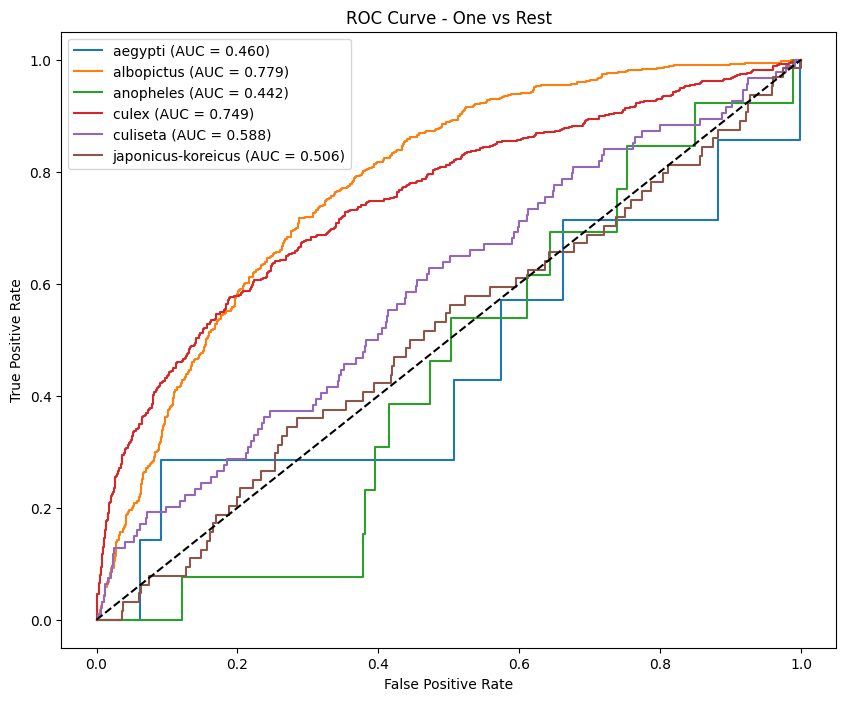

In [20]:
n_classes = len(class_names)

all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

# ===== 2. Plot ROC =====
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One vs Rest")
plt.legend()
plt.show()


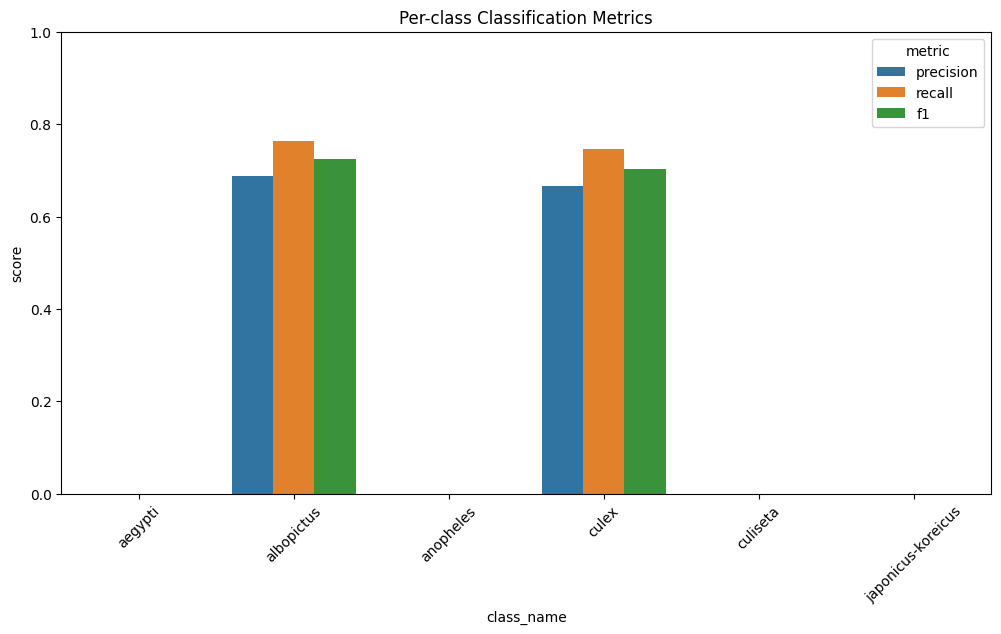

In [21]:
plot_df = per_class_df.melt(
    id_vars=["class_name", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title("Per-class Classification Metrics")
plt.show()


In [22]:
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

# ===== ROC-AUC (One-vs-Rest) =====
roc_auc = roc_auc_score(
    all_labels,
    all_probs,              # shape: (n_samples, n_classes)
    multi_class="ovr",      # one-vs-rest
    average="macro"
)

# ===== Summary table =====
summary_df = pd.DataFrame([{
    "accuracy": acc,
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "roc_auc_ovr": roc_auc
}])

print(summary_df)

   accuracy  precision_macro  recall_macro  f1_macro  roc_auc_ovr
0  0.668597         0.225762      0.251677  0.238016      0.58742
